In [1]:
# This note book is for transfer learning
!pip3 install matplotlib

You should consider upgrading via the '/Users/jjgwerty/Documents/gj/learning/pytorch/pytorch_practice/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import data_setup, engine, get_data, train, utils
from pathlib import Path

/Users/jjgwerty/Documents/gj/learning/pytorch/pytorch_practice/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jjgwerty/Documents/gj/learning/pytorch/pytorch_practice/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
try:
    from torchinfo import summary
except:
    print(f"[INFO] torchinfo not found, installing...")
    !pip3 install torchinfo
    from torchinfo import summary

In [4]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [5]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")

Using device: mps


In [6]:
train_dir = Path("../data/pizza_steak_sushi/train")
test_dir = Path("../data/pizza_steak_sushi/test")

In [7]:
# create data transforms
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir,
    test_dir,
    batch_size=32,
    transform=manual_transforms
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1439f6dc0>,
 ['pizza', 'steak', 'sushi'])

In [9]:
# Get the pretrained model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [10]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [11]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir,
    test_dir,
    transform=auto_transforms,
    batch_size=32
)

In [12]:
# Getting a pretrained model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [13]:
summary(model, input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [14]:
for param in model.parameters():
    param.requires_grad = False

In [15]:
torch.manual_seed(42)
# torch.backends.mps.manual_seed(42)

output_shape = len(class_names)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, 
                    out_features=output_shape,
                    bias=True)).to(device)

summary(model, input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [21]:
# Check a batch device
X, y = next(iter(train_dataloader))
print("batch device:", X.device)

# Check model parameter / buffer devices
for n, p in model.named_parameters():
    print("param", n, p.device)
for n, b in model.named_buffers():
    print("buffer", n, b.device)

batch device: cpu
param features.0.0.weight mps:0
param features.0.1.weight mps:0
param features.0.1.bias mps:0
param features.1.0.block.0.0.weight mps:0
param features.1.0.block.0.1.weight mps:0
param features.1.0.block.0.1.bias mps:0
param features.1.0.block.1.fc1.weight mps:0
param features.1.0.block.1.fc1.bias mps:0
param features.1.0.block.1.fc2.weight mps:0
param features.1.0.block.1.fc2.bias mps:0
param features.1.0.block.2.0.weight mps:0
param features.1.0.block.2.1.weight mps:0
param features.1.0.block.2.1.bias mps:0
param features.2.0.block.0.0.weight mps:0
param features.2.0.block.0.1.weight mps:0
param features.2.0.block.0.1.bias mps:0
param features.2.0.block.1.0.weight mps:0
param features.2.0.block.1.1.weight mps:0
param features.2.0.block.1.1.bias mps:0
param features.2.0.block.2.fc1.weight mps:0
param features.2.0.block.2.fc1.bias mps:0
param features.2.0.block.2.fc2.weight mps:0
param features.2.0.block.2.fc2.bias mps:0
param features.2.0.block.3.0.weight mps:0
param 

In [17]:
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()

results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)
end_time = timer()
print(f"Training time: {end_time - start_time} seconds")

 20%|██        | 1/5 [00:03<00:13,  3.35s/it]

Epoch 1
Train loss: 1.0815 | Train accuracy: 0.4023 | Test loss: 0.8985 | Test accuracy: 0.5909


 40%|████      | 2/5 [00:05<00:07,  2.66s/it]

Epoch 2
Train loss: 0.8574 | Train accuracy: 0.7734 | Test loss: 0.7932 | Test accuracy: 0.8456


 60%|██████    | 3/5 [00:07<00:04,  2.44s/it]

Epoch 3
Train loss: 0.7885 | Train accuracy: 0.7930 | Test loss: 0.7392 | Test accuracy: 0.8561


 80%|████████  | 4/5 [00:09<00:02,  2.31s/it]

Epoch 4
Train loss: 0.7205 | Train accuracy: 0.7500 | Test loss: 0.6350 | Test accuracy: 0.8655


100%|██████████| 5/5 [00:11<00:00,  2.39s/it]

Epoch 5
Train loss: 0.6385 | Train accuracy: 0.7812 | Test loss: 0.6205 | Test accuracy: 0.8665
Training time: 11.97919425 seconds


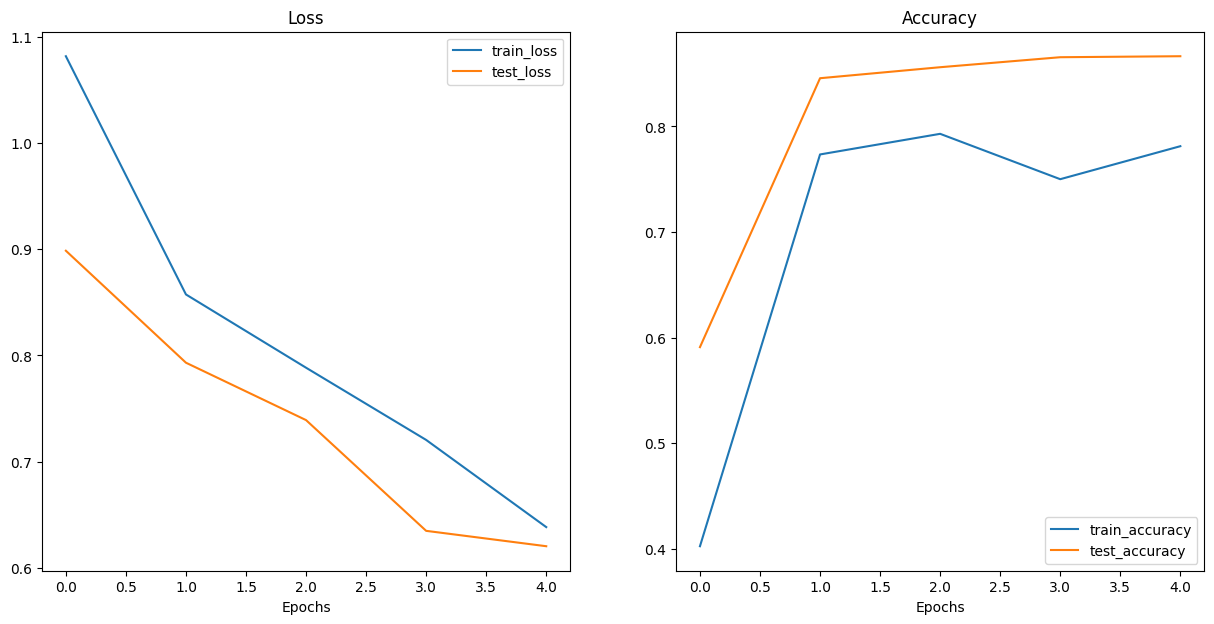

In [19]:
# Evaluate model by plotting loss curves

try:
    from helper_functions import plot_loss_curves
except:
    print(f"[INFO] helper_functions not found, installing...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves
plot_loss_curves(results)

In [23]:
# Load an image and predict on it
from PIL import Image
from typing import List, Tuple, Dict

# 1. Take in trained model, image path, class names, image size, a transform and device to run on 
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: list[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device) -> Dict[str, float]:
# 2. open image
    img = Image.open(image_path)

# 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
###4. Predict on image
    model.to(device)
# 5. Turn on image evaluation and inference mode
    model.eval()
    with torch.inference_mode():
        # 6. transform image and add batch dimension
        transformed_image = image_transform(img).unsqueeze(0).to(device)
        # 7. Make a prediction on the image with an extra dimension and send it to the target device
        target_image_pred = model(transformed_image)
        # 8. Convert predicted logits into prediction probabilites
        target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
        # 9. Convert probabilities to predicted labels
        target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
        # 10. Plot image with predicted label and probability
        plt.figure()
        plt.imshow(img)
        plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
        plt.axis(False)



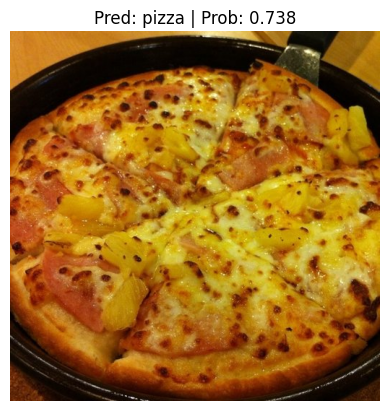

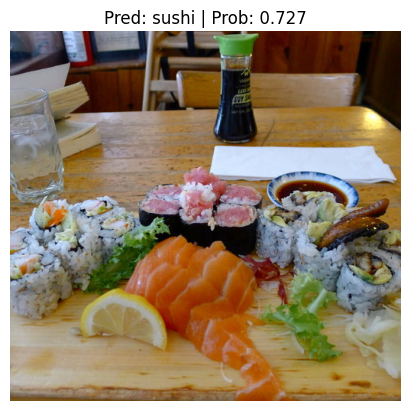

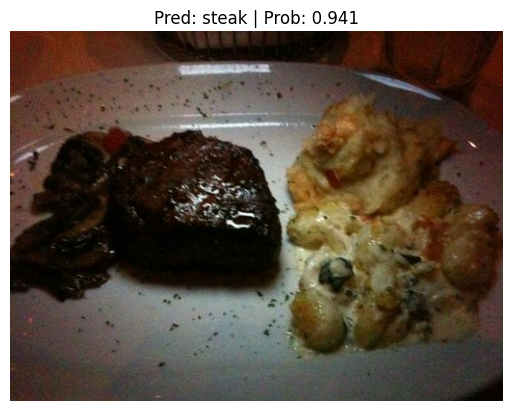

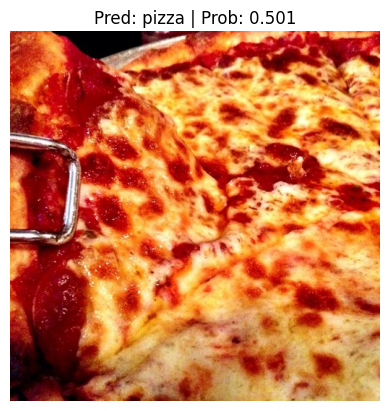

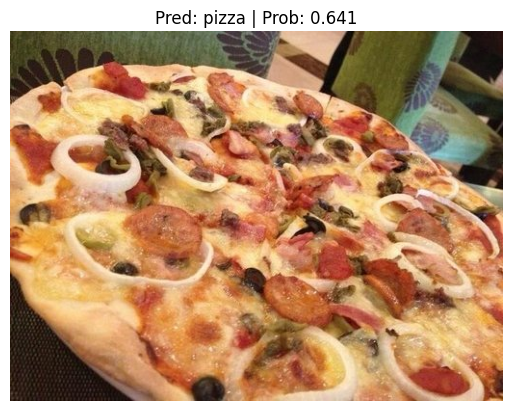

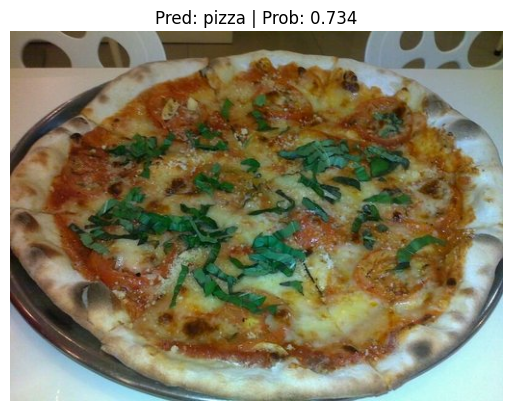

In [30]:
import random
num_image_to_plot = 6
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
test_image_path_sample = random.sample(test_image_path_list, num_image_to_plot)

for image_path in test_image_path_sample:
    pred_and_plot_image(model=model,
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224),
                        transform=None,
                        device=device)

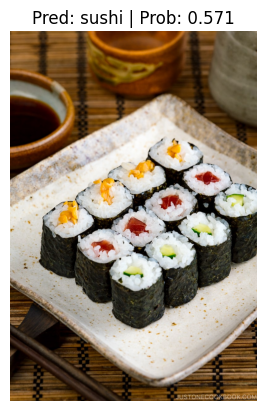

In [54]:
# Get a customer image and predict on it

import requests
# You can download an image save in your data directory with your URL
custom_image_path = Path("../data/Sushi-Rolls-Maki-Sushi.jpg")
custom_image_path.parent.mkdir(parents=True, exist_ok=True)
custom_image_path = custom_image_path.resolve()

# if not custom_image_path.is_file():
#     with open(custom_image_path, "wb") as f:
#         request = requests.get("https://www.justonecookbook.com/sushi-rolls/wp-content/uploads/2020/11/sushi-rolls-500x500.jpg")
#         print(f"Downloading {custom_image_path}...")
#         f.write(request.content)
# else: 
#     print(f"{custom_image_path} already exists, skipping download.")

pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names,
                    image_size=(224, 224),
                    transform=None,
                    device=device)
